# 1. Setup and imports

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Local project root (was a Google Drive path in the Colab version).
PROJECT_ROOT = 'C:/Users/97252/OneDrive/Desktop/DScience'
os.makedirs(f'{PROJECT_ROOT}/data/processed', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/results/figures', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/results/tables', exist_ok=True)

print("Local setup complete, directories created")

Local setup complete, directories created


#**Cache clear**

In [2]:
import shutil

cache_dir = f'{PROJECT_ROOT}/data/processed'
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir, exist_ok=True)
print("✓ Cache cleared")

✓ Cache cleared


#2. Config file

In [3]:
import torch
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 50

NUM_FEATURES = 20
BOTTLENECK_DIM = 4
HIDDEN_DIMS = [16, 8]
DROPOUT_RATE = 0.2

print(f"Config loaded | Features: {NUM_FEATURES} | Bottleneck: {BOTTLENECK_DIM}")

Device: cpu
Config loaded | Features: 20 | Bottleneck: 4


# 3. Data Loading + Feature extraction


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

CICIDS_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd Header Length', 'Bwd Header Length',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
    'Average Packet Size', 'Init_Win_bytes_forward'
]

def load_and_prepare_cicids_ml(data_dir):
    cache_path = f'{data_dir}/processed/features.npz'

    if os.path.exists(cache_path):
        print("Loading from cache...")
        d = np.load(cache_path, allow_pickle=True)
        return (torch.FloatTensor(d['X_train']), torch.FloatTensor(d['X_val']),
                torch.FloatTensor(d['X_test']), torch.LongTensor(d['y_val']),
                torch.LongTensor(d['y_test']))

    csv_dir = f'{data_dir}/raw/MachineLearningCSV/MachineLearningCVE'
    X_list, y_list = [], []
    files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

    for i, file in enumerate(files):
        print(f"  Loading {i+1}/{len(files)}: {file}...")
        df = pd.read_csv(os.path.join(csv_dir, file), low_memory=False)
        df.columns = [c.strip() for c in df.columns]

        missing = [c for c in CICIDS_FEATURES if c not in df.columns]
        if missing:
            raise KeyError(f"Missing expected columns in {file}: {missing}")

        X = df[CICIDS_FEATURES].apply(pd.to_numeric, errors='coerce').values.astype(float)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_list.append(X)

        label_col = next(c for c in df.columns if c.lower() == 'label')
        y = (df[label_col].astype(str).str.strip().str.upper() != 'BENIGN').astype(int).values
        y_list.append(y)
        del df

    X = np.vstack(X_list)
    y = np.hstack(y_list)
    _, keep = np.unique(X, axis=0, return_index=True)
    keep = np.sort(keep)
    X, y = X[keep], y[keep]
    print(f"After de-dup: {len(X):,} rows | Normal {(y==0).sum():,} | Attack {(y==1).sum():,}")
    print(f"  Total: {len(X)} | Normal: {(y==0).sum()} | Attack: {(y==1).sum()}")

    # Train the autoencoder on NORMAL traffic only.
    X_normal, X_attack = X[y == 0], X[y == 1]

    X_tr_norm, X_rest_norm = train_test_split(
        X_normal, test_size=0.4, random_state=RANDOM_STATE)
    X_val_norm, X_test_norm = train_test_split(
        X_rest_norm, test_size=0.5, random_state=RANDOM_STATE)
    X_val_att, X_test_att = train_test_split(
        X_attack, test_size=0.5, random_state=RANDOM_STATE)

    scaler = StandardScaler().fit(X_tr_norm)          # fit on normals only
    X_train = scaler.transform(X_tr_norm)
    X_val   = scaler.transform(np.vstack([X_val_norm, X_val_att]))
    X_test  = scaler.transform(np.vstack([X_test_norm, X_test_att]))
    y_val   = np.hstack([np.zeros(len(X_val_norm)),  np.ones(len(X_val_att))]).astype(int)
    y_test  = np.hstack([np.zeros(len(X_test_norm)), np.ones(len(X_test_att))]).astype(int)

    np.savez(cache_path, X_train=X_train, X_val=X_val, X_test=X_test,
             y_val=y_val, y_test=y_test)

    return (torch.FloatTensor(X_train), torch.FloatTensor(X_val),
            torch.FloatTensor(X_test), torch.LongTensor(y_val),
            torch.LongTensor(y_test))

X_train, X_val, X_test, y_val, y_test = load_and_prepare_cicids_ml(f'{PROJECT_ROOT}/data')
print(f"✓ Data loaded | Train(normal-only): {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"  Val classes:  {np.bincount(y_val.numpy())}")
print(f"  Test classes: {np.bincount(y_test.numpy())}")

  Loading 1/8: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...


  Loading 2/8: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...


  Loading 3/8: Friday-WorkingHours-Morning.pcap_ISCX.csv...


  Loading 4/8: Monday-WorkingHours.pcap_ISCX.csv...


  Loading 5/8: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...


  Loading 6/8: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...


  Loading 7/8: Tuesday-WorkingHours.pcap_ISCX.csv...


  Loading 8/8: Wednesday-workingHours.pcap_ISCX.csv...


After de-dup: 2,185,714 rows | Normal 1,849,684 | Attack 336,030
  Total: 2185714 | Normal: 1849684 | Attack: 336030


✓ Data loaded | Train(normal-only): torch.Size([1109810, 20]) | Val: torch.Size([537952, 20]) | Test: torch.Size([537952, 20])
  Val classes:  [369937 168015]
  Test classes: [369937 168015]


# 4. Exploratory Data Analysis (EDA)

EDA is performed on the raw (pre-scaling) features so distributions reflect the
true data. It covers data quality (missing values, duplicates), column sanity,
feature distributions, outliers, temporal structure, and class imbalance.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def load_eda_frame(data_dir):
    """Load raw features + string labels for EDA (independent of the model pipeline)."""
    csv_dir = f'{data_dir}/raw/MachineLearningCSV/MachineLearningCVE'
    frames = []
    for f in sorted(os.listdir(csv_dir)):
        if not f.endswith('.csv'):
            continue
        d = pd.read_csv(os.path.join(csv_dir, f), low_memory=False)
        d.columns = [c.strip() for c in d.columns]
        label_col = next(c for c in d.columns if c.lower() == 'label')
        d = d[CICIDS_FEATURES + [label_col]].rename(columns={label_col: 'Label'})
        for c in CICIDS_FEATURES:
            d[c] = pd.to_numeric(d[c], errors='coerce').astype('float32')
        frames.append(d)
        del d
    full = pd.concat(frames, ignore_index=True)
    full[CICIDS_FEATURES] = full[CICIDS_FEATURES].replace([np.inf, -np.inf], np.nan)
    full['binary'] = (full['Label'].astype(str).str.strip().str.upper() != 'BENIGN').astype(int)
    return full

eda_full = load_eda_frame(f'{PROJECT_ROOT}/data')
eda_df = eda_full.sample(n=min(200_000, len(eda_full)), random_state=RANDOM_STATE)
print(f"EDA frame: {eda_full.shape} | plotting sample: {eda_df.shape}")

EDA frame: (2830743, 22) | plotting sample: (200000, 22)


### 4.1 Column & index sanity check

In [6]:
print("Columns:", list(eda_full.columns))
print("\nIndex:", eda_full.index)
print("\nDtypes:\n", eda_full[CICIDS_FEATURES].dtypes.value_counts())

Columns: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd Header Length', 'Bwd Header Length', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Average Packet Size', 'Init_Win_bytes_forward', 'Label', 'binary']

Index: RangeIndex(start=0, stop=2830743, step=1)

Dtypes:
 float32    20
Name: count, dtype: int64


The 20 columns are descriptive flow statistics (durations, packet/byte counts,
inter-arrival times) plus the `Label`. Names are self-explanatory and match
CIC-IDS2017's documented schema. The index is a default `RangeIndex` (rows are
independent flow records with no meaningful order), which is appropriate.

### 4.2 Class imbalance / prevalence

Binary class counts:
 binary
0    2273097
1     557646
Name: count, dtype: int64

Attack prevalence in dataset: 19.7%


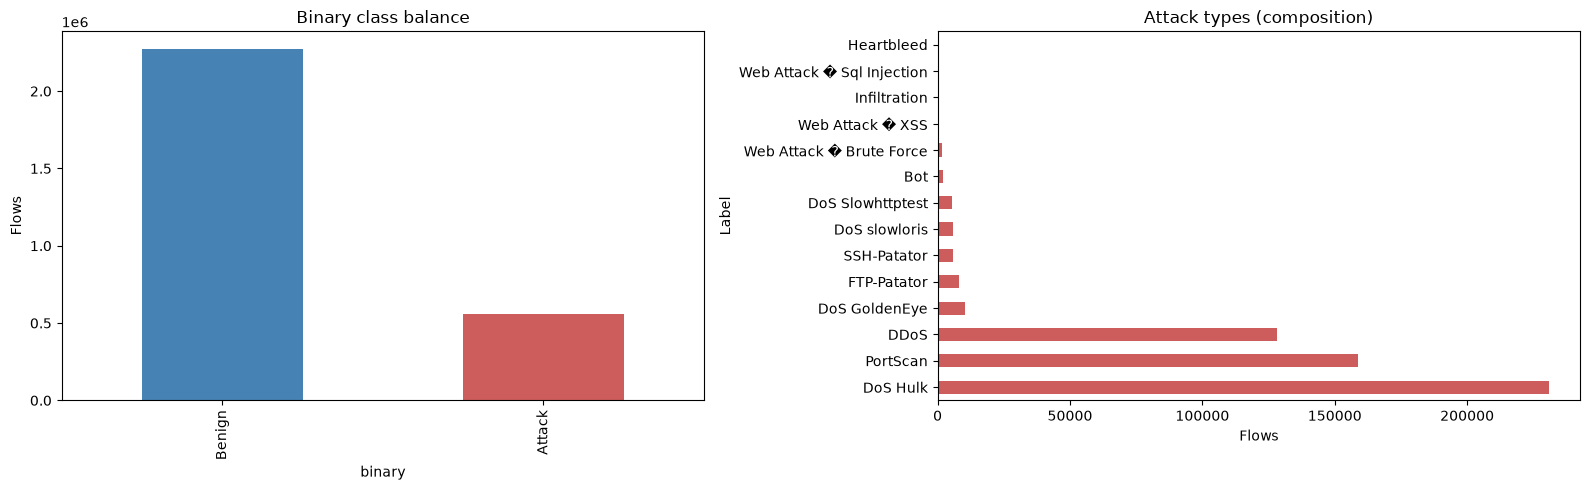

In [7]:
print("Binary class counts:\n", eda_full['binary'].value_counts())
print(f"\nAttack prevalence in dataset: {eda_full['binary'].mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
eda_full['binary'].map({0: 'Benign', 1: 'Attack'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['steelblue', 'indianred'])
ax[0].set_title('Binary class balance'); ax[0].set_ylabel('Flows')

eda_full.loc[eda_full['binary'] == 1, 'Label'].value_counts().plot(
    kind='barh', ax=ax[1], color='indianred')
ax[1].set_title('Attack types (composition)'); ax[1].set_xlabel('Flows')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/class_imbalance.png', dpi=150)
plt.show()

Attacks make up roughly a fifth of this dataset, but this is an artefact of the
controlled capture. In real traffic, attacks are far rarer (well under 1%). This
gap is central to our critique: the source reports an 8.7% false-positive rate on
near-balanced data, but at realistic prevalence that same FPR yields very low
precision (see Section 5.8). The attack composition is itself imbalanced -
volumetric attacks (DoS Hulk, DDoS, PortScan) dominate while stealthy attacks
(Bot, Infiltration, Heartbleed) are rare, which later explains why those classes
are systematically missed.

### 4.3 Missing values & duplicate records (data quality)

In [8]:
print("Missing / non-finite values per feature:")
print(eda_full[CICIDS_FEATURES].isna().sum()[lambda s: s > 0])

n_total = len(eda_full)
n_unique = eda_full[CICIDS_FEATURES].drop_duplicates().shape[0]
print(f"\nDuplicate analysis: {n_total:,} rows, {n_unique:,} unique "
      f"({1 - n_unique/n_total:.1%} duplicates)")

Missing / non-finite values per feature:
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64



Duplicate analysis: 2,830,743 rows, 2,148,899 unique (24.1% duplicates)


**Data-quality findings.** A few features contain non-finite values (infinities
from rate features such as `Flow Bytes/s` divided by near-zero durations), coerced
to NaN. More importantly, a large fraction of all flow records are **exact
duplicates** - a documented flaw of CIC-IDS2017. Because duplicates leak across
random train/test splits, we remove them before splitting (Section 3), and we show
that not doing so inflates performance.

### 4.4 Feature distributions

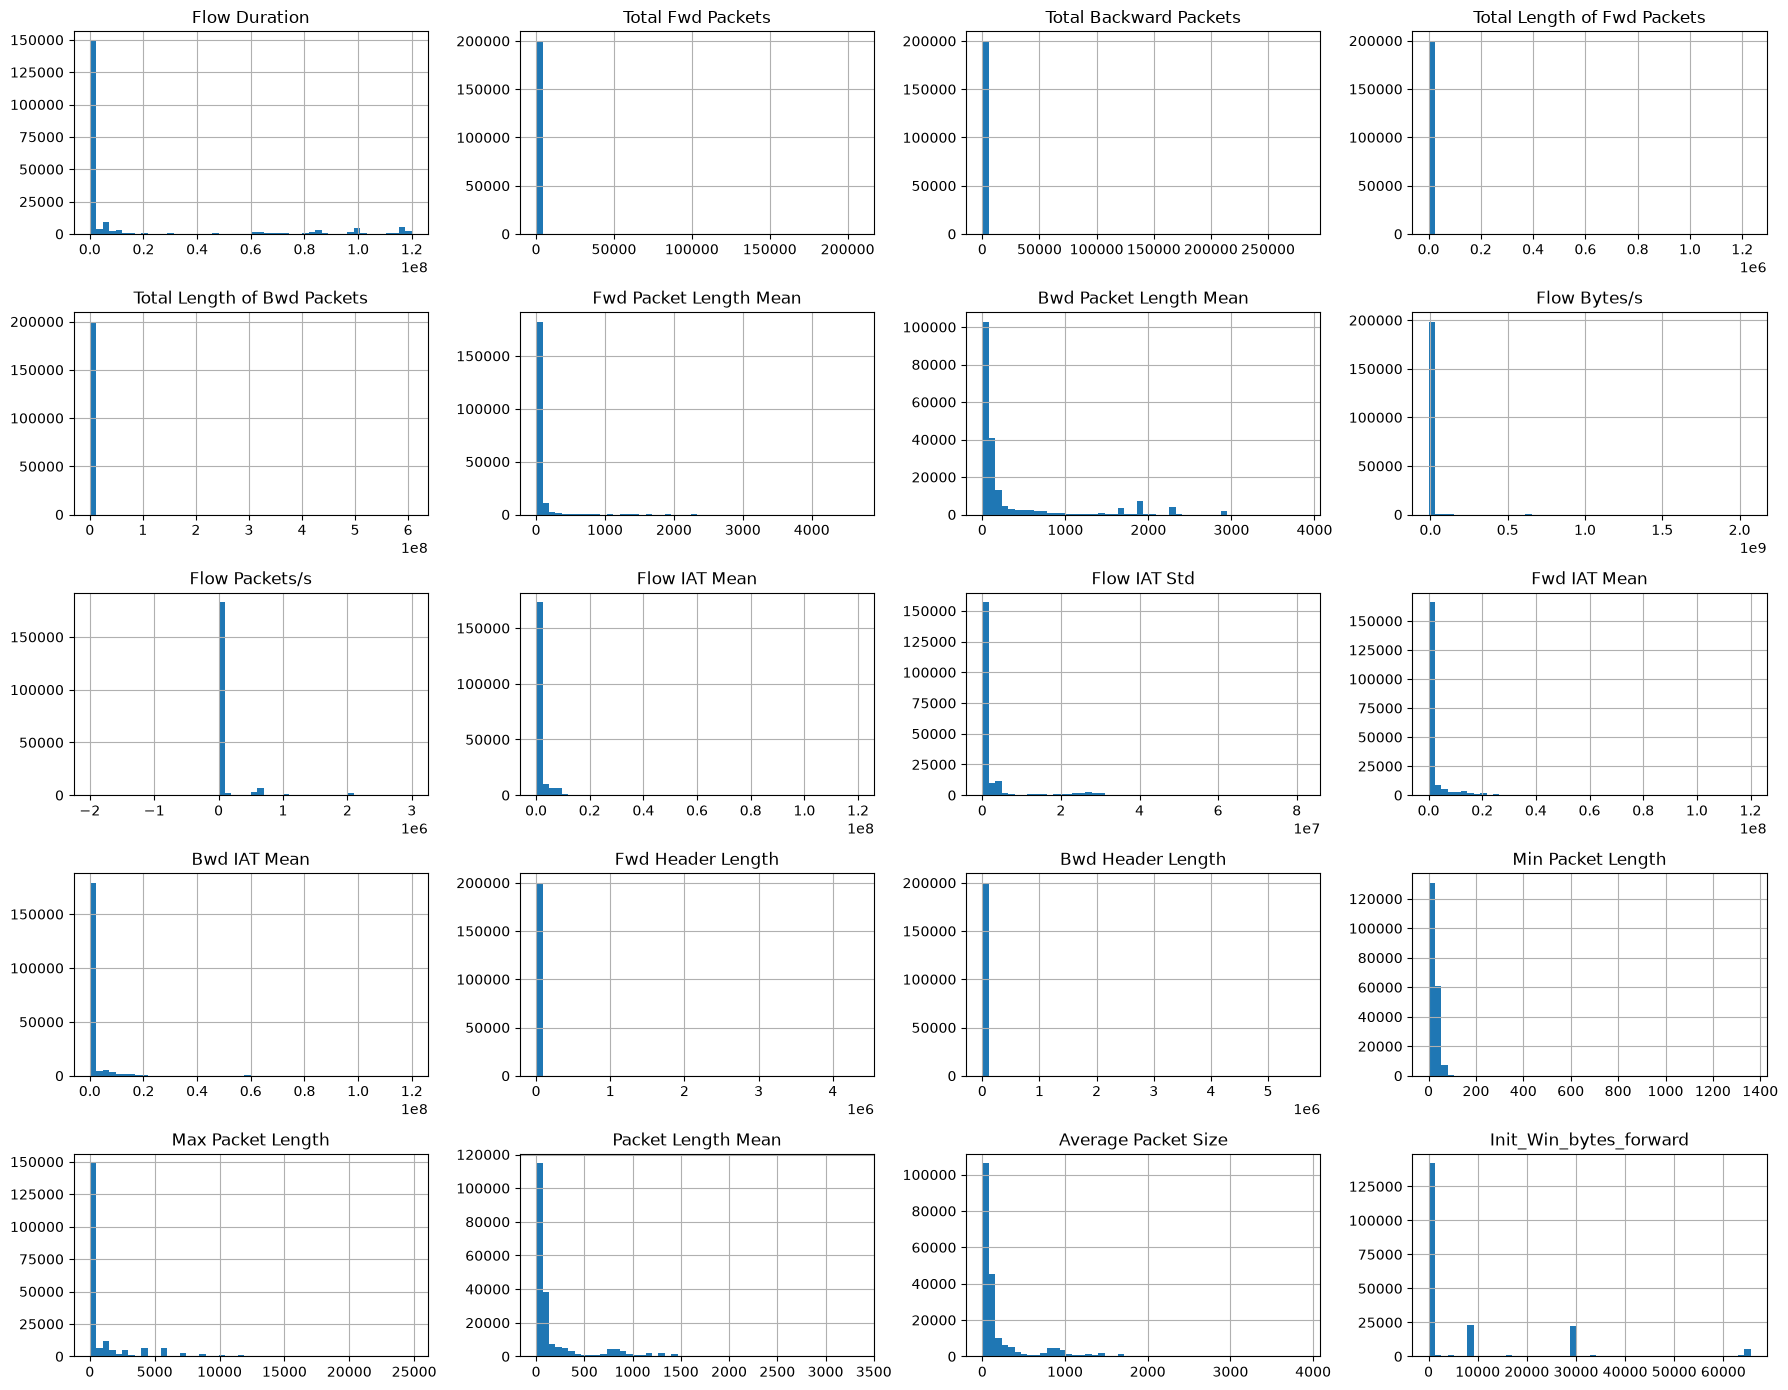

In [9]:
eda_df[CICIDS_FEATURES].hist(bins=50, figsize=(18, 14))
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/feature_distributions.png', dpi=150)
plt.show()

Most features are **heavily right-skewed and heavy-tailed** (a few flows carry
enormous byte/packet counts). This motivates two choices: (1) we standardise rather
than min-max normalise - min-max would let a single extreme value crush all others
toward zero (a weakness of the source's preprocessing); and (2) for correlation we
use Spearman (rank-based), since Pearson assumes linear, roughly-normal
relationships that these distributions violate.

### 4.5 Outlier magnitude

In [10]:
eda_full[CICIDS_FEATURES].describe(percentiles=[.5, .9, .99, .999]).T

,count,mean,std,min,50%,90%,99%,99.9%,max
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,31316.000000,8.470412e+07,1.177776e+08,1.197933e+08,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,1.100000e+01,4.800000e+01,2.730000e+02,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,2.000000,9.000000e+00,5.700000e+01,4.080000e+02,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,62.000000,8.980000e+02,1.159500e+04,3.433600e+04,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,123.000000,1.159500e+04,7.183100e+04,6.898434e+05,6.554531e+08
Fwd Packet Length Mean,2830743.0,5.820193e+01,1.860912e+02,0.000000e+00,34.000000,8.525000e+01,1.035500e+03,2.321400e+03,5.940857e+03
Bwd Packet Length Mean,2830743.0,3.059493e+02,6.052568e+02,0.000000e+00,72.000000,1.278129e+03,2.321400e+03,2.901750e+03,5.800500e+03
Flow Bytes/s,2827876.0,1.491719e+06,2.594016e+07,-2.610000e+08,4586.600586,1.371429e+06,1.233333e+07,2.470000e+08,2.071000e+09
Flow Packets/s,2827876.0,7.085423e+04,2.544154e+05,-2.000000e+06,109.475998,6.451613e+04,2.000000e+06,2.000000e+06,4.000000e+06
Flow IAT Mean,2830743.0,1.298449e+06,4.507944e+06,-1.300000e+01,11438.841797,3.732362e+06,2.140000e+07,6.406481e+07,1.200000e+08


The gap between the 99.9th percentile and the maximum spans several orders of
magnitude for rate/volume features, confirming extreme outliers. These flows later
produce very large reconstruction errors and are why min-max normalisation would be
fragile on this dataset.

### 4.6 Temporal analysis

In [11]:
eda_df[['Flow Duration', 'Flow IAT Mean', 'Flow IAT Std']].describe(
    percentiles=[.5, .9, .99]).T

,count,mean,std,min,50%,90%,99%,max
Flow Duration,200000.0,1.469674e+07,33558760.0,-1.0,31293.500000,8.455801e+07,1.177848e+08,119999976.0
Flow IAT Mean,200000.0,1.283782e+06,4497437.0,-1.0,11309.704590,3.706297e+06,2.100015e+07,120000000.0
Flow IAT Std,200000.0,2.889640e+06,7992056.5,0.0,135.120934,5.352099e+06,3.260000e+07,81926368.0


**Temporal analysis.** The MachineLearningCVE CSVs contain no absolute timestamp
column; temporal information is captured only *within* each flow via duration and
inter-arrival-time (IAT) features. The dataset's broader temporal structure is at
the day level (each day is a distinct attack campaign). Because we model individual
flows, we treat records as i.i.d.; we note this as a limitation - a deployed system
could exploit cross-flow temporal patterns (e.g. beaconing periodicity) that the
per-flow features here cannot represent.

### 4.7 Correlation analysis (Spearman)

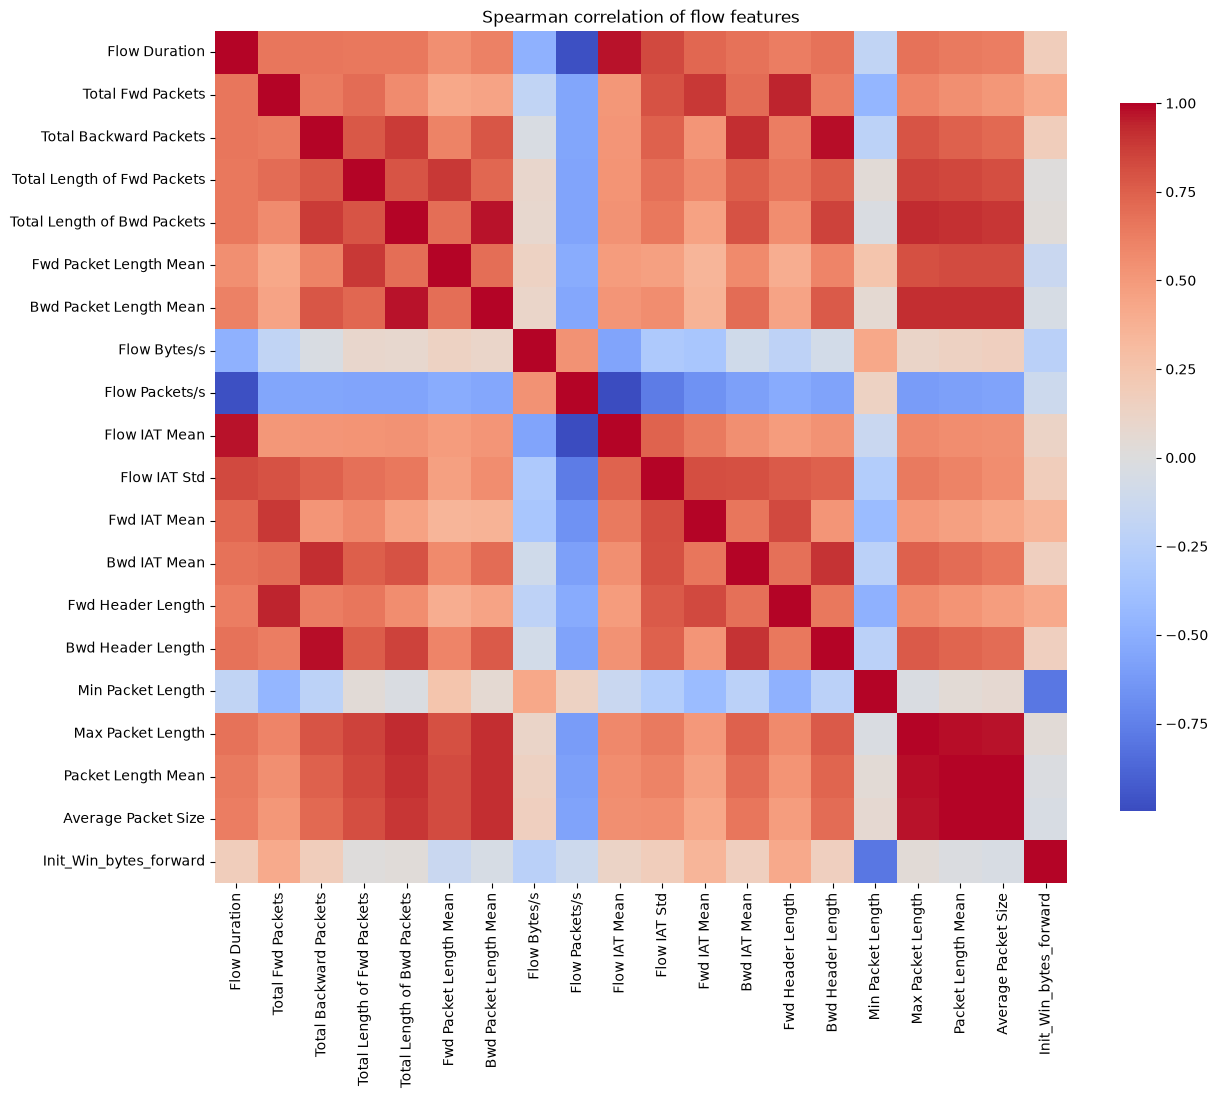

In [12]:
corr = eda_df[CICIDS_FEATURES].corr(method='spearman')
plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Spearman correlation of flow features')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/correlation_heatmap.png', dpi=150)
plt.show()

**Why Spearman.** Pearson measures *linear* association and assumes
roughly-normal, outlier-free data - violated here by the heavy tails. Kendall is
robust but costly on large samples and mainly of interest for small datasets.
Spearman (rank-based) captures monotonic relationships and is robust to the skew
and outliers we observed, making it the appropriate choice. The heatmap shows
strong block structure: many flow statistics are highly redundant (packet-length
means vs averages, byte totals vs byte rates), quantified next.

# 5. Feature Engineering

**Selection.** We use 20 numerical flow features capturing volume, timing, and
size. We deliberately **drop the categorical IP-address and protocol fields** that
the source one-hot encodes: source/destination IP identity risks memorising the
specific hosts used to stage attacks in this capture (an artefact that would not
generalise), so excluding them yields a more honest behavioural detector.

**Scaling.** Standardisation (z-scoring) is fitted on benign training data only, so
preprocessing leaks no test/attack information.

**Dimensionality reduction.** We do not apply PCA separately - the autoencoder's
20->4 bottleneck *is* a learned, non-linear dimensionality reduction, compressing
the redundant feature set (quantified below) into four latent factors.

In [13]:
import itertools

redundant = [(a, b, round(float(corr.loc[a, b]), 3))
             for a, b in itertools.combinations(CICIDS_FEATURES, 2)
             if abs(corr.loc[a, b]) > 0.9]
redundant = sorted(redundant, key=lambda t: -abs(t[2]))
print("Highly correlated feature pairs (|Spearman| > 0.9):")
for a, b, r in redundant:
    print(f"  {a:32s} ~ {b:32s} {r:+.3f}")

Highly correlated feature pairs (|Spearman| > 0.9):
  Flow Packets/s                   ~ Flow IAT Mean                    -0.996
  Packet Length Mean               ~ Average Packet Size              +0.996
  Max Packet Length                ~ Packet Length Mean               +0.983
  Flow Duration                    ~ Flow Packets/s                   -0.980
  Total Backward Packets           ~ Bwd Header Length                +0.978
  Max Packet Length                ~ Average Packet Size              +0.974
  Total Length of Bwd Packets      ~ Bwd Packet Length Mean           +0.971
  Flow Duration                    ~ Flow IAT Mean                    +0.969
  Total Fwd Packets                ~ Fwd Header Length                +0.945
  Total Length of Bwd Packets      ~ Max Packet Length                +0.924
  Total Backward Packets           ~ Bwd IAT Mean                     +0.922
  Bwd Packet Length Mean           ~ Packet Length Mean               +0.920
  Bwd Packet Length Mean

These pairs are near-duplicates of one another - redundancy that linear models
would handle poorly (multicollinearity) but which the autoencoder's bottleneck
absorbs by design. Spotting redundancy via rank correlation, and removing it through
either pair-pruning or the bottleneck, is the practical mitigation.

# 6. Model Definition and Training

### 6.1 Model Definition

In [14]:
import torch.nn as nn


class Autoencoder(nn.Module):
    def __init__(self, input_dim=NUM_FEATURES, bottleneck_dim=BOTTLENECK_DIM,
                 hidden_dims=None, dropout_rate=DROPOUT_RATE):
        super(Autoencoder, self).__init__()

        if hidden_dims is None:
            hidden_dims = HIDDEN_DIMS

        encoder_layers = []
        dims = [input_dim] + hidden_dims + [bottleneck_dim]
        for i in range(len(dims) - 1):
            encoder_layers.append(nn.Linear(dims[i], dims[i+1]))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(dropout_rate))
        encoder_layers.pop()
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        dims = [bottleneck_dim] + list(reversed(hidden_dims)) + [input_dim]
        for i in range(len(dims) - 1):
            decoder_layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                decoder_layers.append(nn.ReLU())
                decoder_layers.append(nn.Dropout(dropout_rate))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


model = Autoencoder().to(DEVICE)
print(f"Model created | Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created | Parameters: 1,032


### 6.2 Model Training

In [15]:
from torch.utils.data import TensorDataset, DataLoader


def train_autoencoder(model, X_train, epochs=EPOCHS, lr=LEARNING_RATE, val_frac=0.1):
    n_val = int(len(X_train) * val_frac)
    perm = torch.randperm(len(X_train))
    X_mon = X_train[perm[:n_val]]          # normal-only monitoring set
    X_fit = X_train[perm[n_val:]]

    train_loader = DataLoader(TensorDataset(X_fit), batch_size=BATCH_SIZE, shuffle=True)
    mon_loader   = DataLoader(TensorDataset(X_mon), batch_size=BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')

    for epoch in range(epochs):
        model.train()
        tl = 0
        for (batch_X,) in train_loader:
            batch_X = batch_X.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_X)
            loss.backward()
            optimizer.step()
            tl += loss.item()
        tl /= len(train_loader)

        model.eval()
        vl = 0
        with torch.no_grad():
            for (batch_X,) in mon_loader:
                batch_X = batch_X.to(DEVICE)
                vl += criterion(model(batch_X), batch_X).item()
        vl /= len(mon_loader)

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), f'{PROJECT_ROOT}/checkpoints/best_model.pt')
            print(f"Epoch {epoch+1}/{epochs} | Train: {tl:.4f} | NormalHoldout: {vl:.4f} | ✓ Checkpoint saved")
        elif (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train: {tl:.4f} | NormalHoldout: {vl:.4f}")

    model.load_state_dict(torch.load(f'{PROJECT_ROOT}/checkpoints/best_model.pt'))
    return model, history


print("Training on normal traffic only...")
model, history = train_autoencoder(model, X_train)
print("✓ Training complete (best checkpoint reloaded)")

Training on normal traffic only...


Epoch 1/50 | Train: 0.6645 | NormalHoldout: 0.4763 | ✓ Checkpoint saved


Epoch 2/50 | Train: 0.6005 | NormalHoldout: 0.3992 | ✓ Checkpoint saved


Epoch 3/50 | Train: 0.5496 | NormalHoldout: 0.3347 | ✓ Checkpoint saved


Epoch 4/50 | Train: 0.5326 | NormalHoldout: 0.3087 | ✓ Checkpoint saved


...

Epoch 12/50 | Train: 0.5185 | NormalHoldout: 0.2307 | ✓ Checkpoint saved


Epoch 20/50 | Train: 0.4986 | NormalHoldout: 0.2370


Epoch 30/50 | Train: 0.4800 | NormalHoldout: 0.3047


Epoch 40/50 | Train: 0.4838 | NormalHoldout: 0.3548


Epoch 50/50 | Train: 0.4846 | NormalHoldout: 0.2443
✓ Training complete (best checkpoint reloaded)


# 7. Evaluation



## 7.1 Visualizing training history

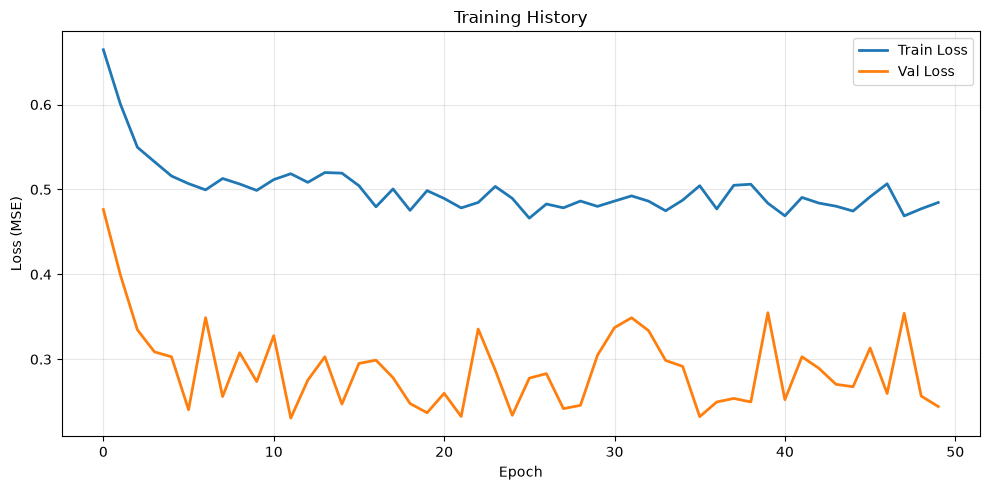

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/training_history.png', dpi=150)
plt.show()

## 7.2 Compute Reconstruction Errors

In [17]:
from sklearn.metrics import (precision_score, recall_score, f1_score, fbeta_score,
                             matthews_corrcoef, confusion_matrix, roc_auc_score,
                             roc_curve, auc, accuracy_score)

def compute_reconstruction_errors(model, X, device=DEVICE):
    model.eval()
    X = X.to(device)
    with torch.no_grad():
        errors = ((X - model(X)) ** 2).mean(dim=1)
    return errors.cpu().numpy()

def evaluate_threshold(errors, y_true, threshold):
    y_pred = (errors > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'f2': fbeta_score(y_true, y_pred, beta=2.0, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, errors) if len(np.unique(y_true)) == 2 else np.nan,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    }

val_errors  = compute_reconstruction_errors(model, X_val)
test_errors = compute_reconstruction_errors(model, X_test)
print(f"Val:  min {val_errors.min():.4f}  max {val_errors.max():.4f}")
print(f"Test: min {test_errors.min():.4f}  max {test_errors.max():.4f}")

Val:  min 0.0013  max 13740.8311
Test: min 0.0012  max 143049.9688


## 7.3 Select Optimal Threshold

In [18]:
from sklearn.metrics import precision_recall_curve

# One sorted pass gives precision/recall at every threshold.
precision, recall, thr = precision_recall_curve(y_val.numpy(), val_errors)
precision, recall = precision[:-1], recall[:-1]      # last point has no threshold
f1 = 2 * precision * recall / (precision + recall + 1e-12)

best_i = int(np.argmax(f1))
best_threshold = float(thr[best_i])

print(f"Selected threshold (max F1 on val): {best_threshold:.6f}")
print(f"  val precision: {precision[best_i]:.4f}  recall: {recall[best_i]:.4f}  f1: {f1[best_i]:.4f}")

# Final, honest report: one evaluation on the held-out TEST set.
test_metrics = evaluate_threshold(test_errors, y_test.numpy(), best_threshold)
print("\nTEST metrics at val-selected threshold:")
for k in ['accuracy', 'precision', 'recall', 'f1', 'f2', 'mcc', 'roc_auc']:
    print(f"  {k}: {test_metrics[k]:.4f}")

Selected threshold (max F1 on val): 0.866931
  val precision: 0.8931  recall: 0.7338  f1: 0.8056



TEST metrics at val-selected threshold:
  accuracy: 0.8902
  precision: 0.8938
  recall: 0.7360
  f1: 0.8073
  f2: 0.7630
  mcc: 0.7383
  roc_auc: 0.8954


## 7.4 Plot Threshold Selection

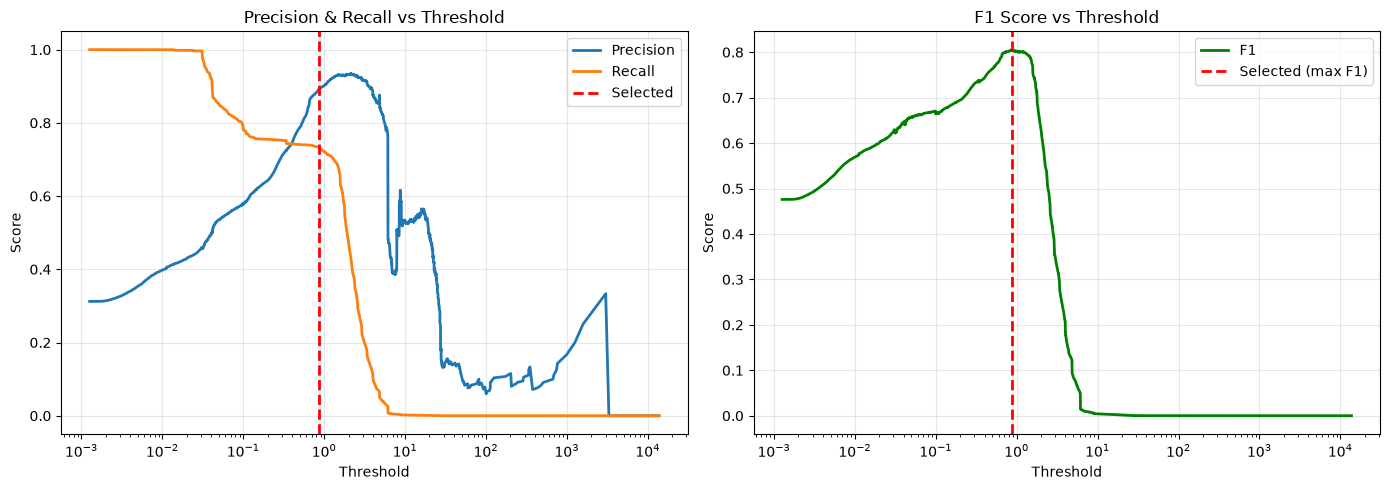

In [19]:
from sklearn.metrics import precision_recall_curve

# Recompute the precision-recall curve for plotting (same as 5.3 did).
precision, recall, thr = precision_recall_curve(y_val.numpy(), val_errors)
precision, recall = precision[:-1], recall[:-1]
f1 = 2 * precision * recall / (precision + recall + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thr, precision, label='Precision', linewidth=2)
axes[0].plot(thr, recall, label='Recall', linewidth=2)
axes[0].axvline(best_threshold, color='red', linestyle='--', label='Selected', linewidth=2)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision & Recall vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

axes[1].plot(thr, f1, linewidth=2, color='green', label='F1')
axes[1].axvline(best_threshold, color='red', linestyle='--', linewidth=2, label='Selected (max F1)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/threshold_selection.png', dpi=150)
plt.show()

## 7.5 Reconstruction Error Distribution

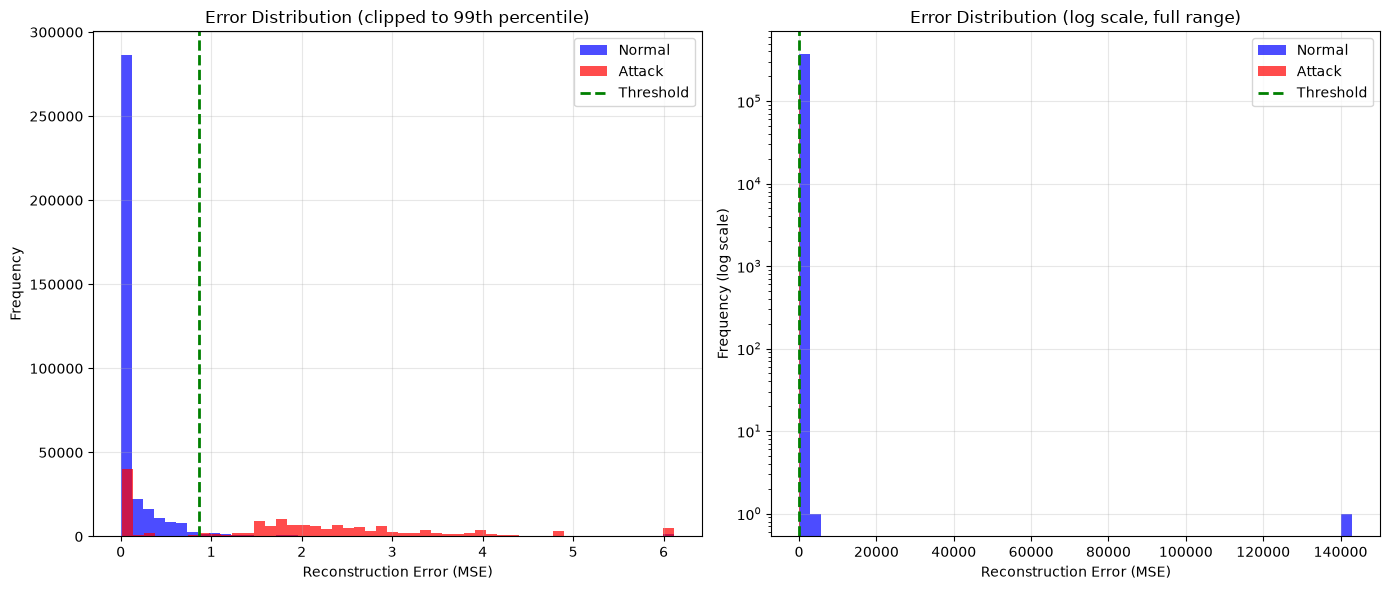

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Linear scale, clipped to 99th percentile (readable)
clip_val = np.percentile(test_errors, 99)
test_errors_clipped = np.clip(test_errors, 0, clip_val)

axes[0].hist(test_errors_clipped[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
axes[0].hist(test_errors_clipped[y_test == 1], bins=50, alpha=0.7, label='Attack', color='red')
axes[0].axvline(best_threshold, color='green', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Error Distribution (clipped to 99th percentile)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Log scale (shows full range including outliers)
axes[1].hist(test_errors[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
axes[1].hist(test_errors[y_test == 1], bins=50, alpha=0.7, label='Attack', color='red')
axes[1].axvline(best_threshold, color='green', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Error Distribution (log scale, full range)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/error_distribution.png', dpi=150)
plt.show()

## 7.6 ROC Curve

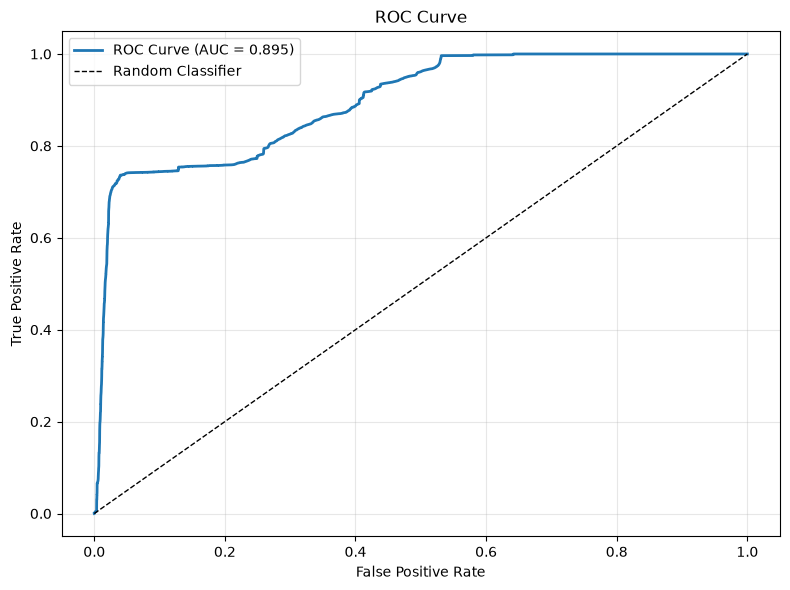

ROC-AUC: 0.8954


In [21]:
fpr, tpr, _ = roc_curve(y_test.numpy(), test_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/roc_curve.png', dpi=150)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

## 7.7 Error Analysis

In [22]:
y_pred = (test_errors > best_threshold).astype(int)

fn_mask = (y_test.numpy() == 1) & (y_pred == 0)
fp_mask = (y_test.numpy() == 0) & (y_pred == 1)

fn_count = fn_mask.sum()
fp_count = fp_mask.sum()

print(f"False Negatives (Missed Attacks): {fn_count}")
print(f"False Positives (False Alarms): {fp_count}")

if fn_count > 0:
    fn_errors = test_errors[fn_mask]
    print(f"\nFN Error Stats:")
    print(f"  Mean: {fn_errors.mean():.4f}")
    print(f"  Std: {fn_errors.std():.4f}")
    print(f"  Max: {fn_errors.max():.4f}")

if fp_count > 0:
    fp_errors = test_errors[fp_mask]
    print(f"\nFP Error Stats:")
    print(f"  Mean: {fp_errors.mean():.4f}")
    print(f"  Std: {fp_errors.std():.4f}")
    print(f"  Min: {fp_errors.min():.4f}")

False Negatives (Missed Attacks): 44351
False Positives (False Alarms): 14697

FN Error Stats:
  Mean: 0.0907
  Std: 0.1276
  Max: 0.8665

FP Error Stats:
  Mean: 13.8731
  Std: 1180.7992
  Min: 0.8671


## 7.8 Prevalence-Aware Analysis

In [23]:
tn = test_metrics['tn']
fp = test_metrics['fp']
fn = test_metrics['fn']
tp = test_metrics['tp']

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

def precision_at_prevalence(recall, fpr, prevalence):
    tp_p = recall * prevalence
    fp_p = fpr * (1.0 - prevalence)
    return tp_p / (tp_p + fp_p) if (tp_p + fp_p) > 0 else 0

print("Precision at Different Attack Prevalences:")
print(f"(Recall: {recall:.4f}, FPR: {fpr:.4f})\n")

prevalences = [0.01, 0.001, 0.0001]
for p in prevalences:
    prec = precision_at_prevalence(recall, fpr, p)
    print(f"  Prevalence {p*100:.2f}%: Precision = {prec:.4f}")

Precision at Different Attack Prevalences:
(Recall: 0.7360, FPR: 0.0397)

  Prevalence 1.00%: Precision = 0.1576
  Prevalence 0.10%: Precision = 0.0182
  Prevalence 0.01%: Precision = 0.0018


## 7.9 Latent Space Visualization

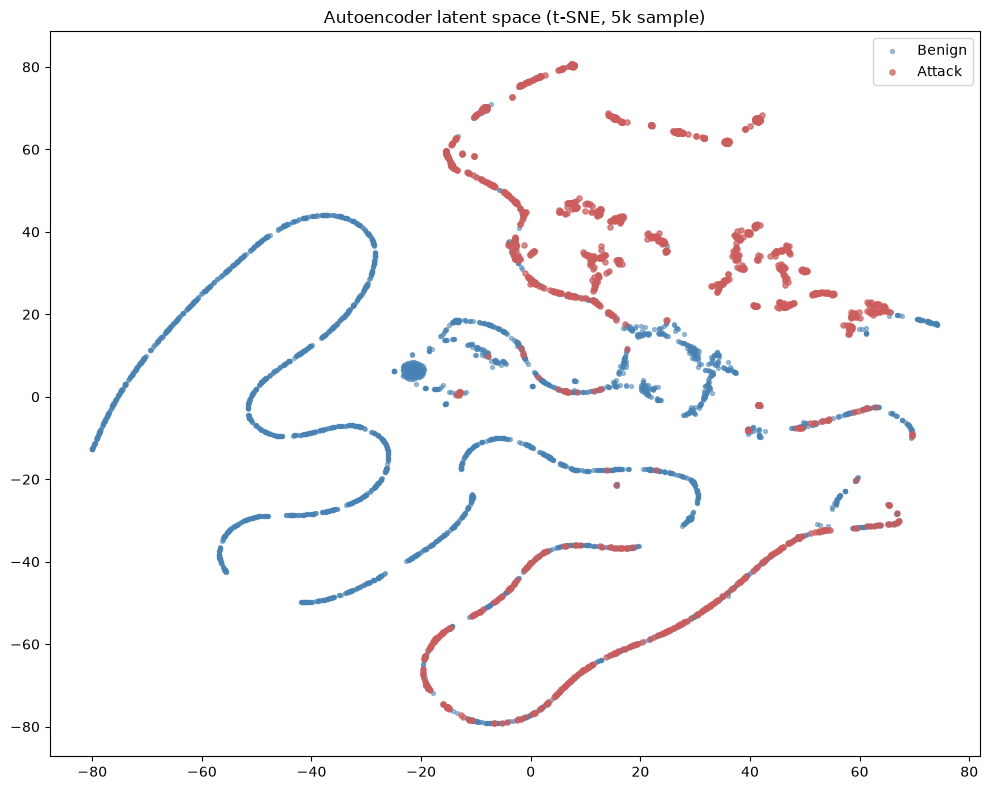

In [24]:
from sklearn.manifold import TSNE

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_test), size=5000, replace=False)

model.eval()
with torch.no_grad():
    latent = model.encode(X_test[idx].to(DEVICE)).cpu().numpy()
y_sub = y_test.numpy()[idx]

emb = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca',
           perplexity=30).fit_transform(latent)

plt.figure(figsize=(10, 8))
plt.scatter(emb[y_sub == 0, 0], emb[y_sub == 0, 1], s=8, alpha=0.5,
            c='steelblue', label='Benign')
plt.scatter(emb[y_sub == 1, 0], emb[y_sub == 1, 1], s=14, alpha=0.7,
            c='indianred', label='Attack')
plt.title('Autoencoder latent space (t-SNE, 5k sample)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/latent_space.png', dpi=150)
plt.show()

# 8. Second Model: Isolation Forest

We train a second, structurally different anomaly detector - an Isolation Forest -
on the same benign-only training data, score the same test set, and select its
threshold the same way (max F1 on validation). This tests whether the autoencoder's
performance reflects the data's separability or is method-specific, and satisfies
the requirement to train at least two models.

In [25]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, max_samples=256, contamination='auto',
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train.numpy())                      # benign-only, like the autoencoder

# Higher score = more anomalous.
val_scores_if  = -iso.score_samples(X_val.numpy())
test_scores_if = -iso.score_samples(X_test.numpy())

# Threshold = max F1 on validation (same protocol as the autoencoder).
p_if, r_if, t_if = precision_recall_curve(y_val.numpy(), val_scores_if)
p_if, r_if = p_if[:-1], r_if[:-1]
f1_if = 2 * p_if * r_if / (p_if + r_if + 1e-12)
thr_if = float(t_if[int(np.argmax(f1_if))])

if_metrics = evaluate_threshold(test_scores_if, y_test.numpy(), thr_if)
print("Isolation Forest - TEST metrics:")
for k in ['accuracy', 'precision', 'recall', 'f1', 'f2', 'mcc', 'roc_auc']:
    print(f"  {k}: {if_metrics[k]:.4f}")

Isolation Forest - TEST metrics:
  accuracy: 0.8661
  precision: 0.8188
  recall: 0.7337
  f1: 0.7739
  f2: 0.7492
  mcc: 0.6813
  roc_auc: 0.8682


In [26]:
comparison = pd.DataFrame({
    'Autoencoder': {k: test_metrics[k] for k in
                    ['roc_auc', 'precision', 'recall', 'f1', 'f2', 'mcc', 'accuracy']},
    'IsolationForest': {k: if_metrics[k] for k in
                        ['roc_auc', 'precision', 'recall', 'f1', 'f2', 'mcc', 'accuracy']},
}).round(4)
print(comparison)
comparison.to_csv(f'{PROJECT_ROOT}/results/tables/model_comparison.csv')
comparison

           Autoencoder  IsolationForest
roc_auc         0.8954           0.8682
precision       0.8938           0.8188
recall          0.7360           0.7337
f1              0.8073           0.7739
f2              0.7630           0.7492
mcc             0.7383           0.6813
accuracy        0.8902           0.8661


,Autoencoder,IsolationForest
roc_auc,0.8954,0.8682
precision,0.8938,0.8188
recall,0.7360,0.7337
f1,0.8073,0.7739
f2,0.7630,0.7492
mcc,0.7383,0.6813
accuracy,0.8902,0.8661


## 9. Final Summary

In [27]:
print("=" * 60)
print("PROJECT SUMMARY - Autoencoder vs Isolation Forest on CIC-IDS2017")
print("=" * 60)

print("\nData (after de-duplication):")
print(f"  Train (benign-only): {len(X_train):,}")
print(f"  Val:  {len(X_val):,}  |  Test: {len(X_test):,}")

print("\nAutoencoder (test):")
for k in ['roc_auc', 'precision', 'recall', 'f1', 'mcc']:
    print(f"  {k}: {test_metrics[k]:.4f}")

print("\nIsolation Forest (test):")
for k in ['roc_auc', 'precision', 'recall', 'f1', 'mcc']:
    print(f"  {k}: {if_metrics[k]:.4f}")

print("\nPrevalence-aware precision (autoencoder):")
recall_ae = test_metrics['tp'] / (test_metrics['tp'] + test_metrics['fn'])
fpr_ae = test_metrics['fp'] / (test_metrics['fp'] + test_metrics['tn'])
for p in [0.01, 0.001, 0.0001]:
    prec = (recall_ae * p) / (recall_ae * p + fpr_ae * (1 - p))
    print(f"  @ {p*100:.2f}% prevalence: precision = {prec:.4f}")

print("\nKey critique: source claims 98.3% TPR / 8.7% FPR; under leakage-free,")
print("prevalence-aware evaluation, precision collapses at realistic attack rates.")
print("=" * 60)

PROJECT SUMMARY - Autoencoder vs Isolation Forest on CIC-IDS2017

Data (after de-duplication):
  Train (benign-only): 1,109,810
  Val:  537,952  |  Test: 537,952

Autoencoder (test):
  roc_auc: 0.8954
  precision: 0.8938
  recall: 0.7360
  f1: 0.8073
  mcc: 0.7383

Isolation Forest (test):
  roc_auc: 0.8682
  precision: 0.8188
  recall: 0.7337
  f1: 0.7739
  mcc: 0.6813

Prevalence-aware precision (autoencoder):
  @ 1.00% prevalence: precision = 0.1576
  @ 0.10% prevalence: precision = 0.0182
  @ 0.01% prevalence: precision = 0.0018

Key critique: source claims 98.3% TPR / 8.7% FPR; under leakage-free,
prevalence-aware evaluation, precision collapses at realistic attack rates.
